# **Agentic RAG In LangGraph**

In [2]:
from langchain_core.messages import HumanMessage;
from langchain_mistralai import ChatMistralAI;
from typing import TypedDict, Literal;
from dotenv import load_dotenv;
import operator;

load_dotenv();

llm = ChatMistralAI(model="mistral-small-2506");

class State(TypedDict):
    question: str;
    documents: list[str];
    generation: str;
    doc_grade: str;
    rewrite_count: int;

DOCS = {
    "langgraph": "LangGraph is a library for building stateful multi-actor LLM applications.",
    "langchain": "LangChain is a framework for LLM-powered applications.",
    "checkpoints": "Checkpoints in LangGraph save and restore agent state across sessions.",
    "tools": "Tools are functions agents use to interact with external systems."
};

def mock_retrieve(query: str) -> list[str]:

    q = query.lower();

    return [doc for key, doc in DOCS.items() if key in q];

In [3]:
def retrieve_node(state: State) -> dict:

    docs = mock_retrieve(state["question"]);

    print(f"[retrieve] Found {len(docs)} docs for: {state["question"]}");

    return {"documents": docs};

def grade_node(state: State) -> dict:

    grade = "useful" if state["documents"] else "not_useful";

    print(f"[grade] → {grade}");

    return {"doc_grade": grade};

def rewrite_node(state: State) -> dict:

    resp = llm.invoke([HumanMessage(f"Rewrite to improve search: {state["question"]}")]);

    count = state.get("rewrite_count", 0) + 1;

    print(f"[rewrite #{count}] → {resp.content[:60]}");

    return {"question": resp.content, "rewrite_count": count};

def generate_node(state: State) -> dict:

    context = "\n".join(state["documents"]) or "No relevant docs.";

    resp = llm.invoke([HumanMessage(f"Answer based on context.\nContext:\n{context}\nQuestion: {state["question"]}")]);

    print("[generate] Answer ready.");

    return {"generation": resp.content};

def route_grade(state: State) -> Literal["generate", "rewrite_query"]:

    if state["doc_grade"] == "useful" or state.get("rewrite_count", 0) >= 2:

        return "generate";

    return "rewrite_query";

In [4]:
from langgraph.graph import StateGraph, START, END;

builder = StateGraph(State);

builder.add_node("retrieve", retrieve_node);

builder.add_node("grade", grade_node);

builder.add_node("rewrite_query", rewrite_node);

builder.add_node("generate", generate_node);

builder.add_edge(START, "retrieve");

builder.add_edge("retrieve", "grade");

builder.add_conditional_edges(
    "grade", 
    route_grade, 
    {
        "generate": "generate", 
        "rewrite_query": "rewrite_query"
    }
);

builder.add_edge("rewrite_query", "retrieve"); # Loop With New Query

builder.add_edge("generate", END);

graph = builder.compile();

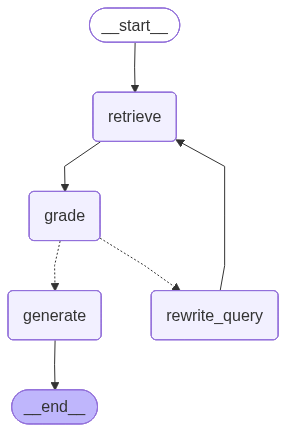

In [5]:
from IPython.display import Image, display;

display(Image(graph.get_graph().draw_mermaid_png()));

In [9]:
question = "What is LangGraph?";

print(f"\n{"="*50}\n❓ {question}");

r = graph.invoke(
    {
        "question": question,
        "documents": [],
        "generation": "",
        "doc_grade": "",
        "rewrite_count": 0
    }
);

print(f"✅ {r["generation"]}");


❓ What is LangGraph?
[retrieve] Found 1 docs for: What is LangGraph?
[grade] → useful
[generate] Answer ready.
✅ Based on the provided context, **LangGraph** is a library designed for building **stateful multi-actor LLM (Large Language Model) applications**.

This implies that LangGraph facilitates the development of applications where multiple AI agents (actors) interact with each other while maintaining state (memory of previous interactions or data). It likely provides tools to manage complex workflows, state transitions, and coordination between different AI components in an LLM-based system.

Would you like more details or examples of its use cases?


In [10]:
question = "how do i save agent progress?";

print(f"\n{"="*50}\n❓ {question}");

r = graph.invoke(
    {
        "question": question,
        "documents": [],
        "generation": "",
        "doc_grade": "",
        "rewrite_count": 0
    }
);

print(f"✅ {r["generation"]}");


❓ how do i save agent progress?
[retrieve] Found 0 docs for: how do i save agent progress?
[grade] → not_useful
[rewrite #1] → Here’s a more search-friendly and optimized version of your 
[retrieve] Found 0 docs for: Here’s a more search-friendly and optimized version of your question:

**"How to Save Agent Progress in [Software/Tool Name]"**

### Why this works better:
1. **Clearer Intent** – Specifies the action ("save") and the subject ("agent progress").
2. **More Searchable** – Includes a placeholder for the specific tool (e.g., "ChatGPT," "AI Assistant," "CRM Software").
3. **Grammar Fix** – "How to" is more natural for search queries than "how do I."

### Example Variations:
- **"How to Save Agent Progress in ChatGPT?"**
- **"How Do I Save an AI Agent’s Progress?"**
- **"Where Are Agent Progress Files Stored in [Tool Name]?"**
[grade] → not_useful
[rewrite #2] → Here’s an even more refined and search-optimized version of 
[retrieve] Found 0 docs for: Here’s an even more refined